In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [3]:
pretrained_net = torchvision.models.resnet18(pretrained=True)
# orchvision.models.resnet18(...)：构造一个 ResNet-18 模型。
# pretrained=True：
# 表示加载在 ImageNet 数据集上训练好的权重（1000 类分类任务）
list(pretrained_net.children())[-3:]
# .children() 是 PyTorch nn.Module 的方法

[Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (downsample): Sequential(
       (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
       (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
   )
   (1): BasicBlock(
     (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): Batc

In [6]:
net = nn.Sequential(*list(pretrained_net.children())[:-2])
# * 把 list 里的模块逐个作为参数传入 nn.Sequential。
# nn.Sequential 会把这些模块按顺序串起来，形成一个新的网络 net

In [7]:
X = torch.rand(size=(1, 3, 320, 480))
net(X).shape

torch.Size([1, 512, 10, 15])

In [8]:
num_classes = 21
# VOC 语义分割共有 21 类（含背景）
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
# 在 backbone 输出的特征图上做一个 1×1 卷积，把通道数从 512 变成 21。
# 输入通道：512（ResNet-18 的 layer4 输出通道数）
# 输出通道：num_classes=21
# kernel_size=1：1×1 卷积，只做通道混合，不改变空间大小
# 形状变化（举例）
# 如果输入原图是 (N,3,H,W)，ResNet18 到 layer4 的输出一般是：
# (N, 512, H/32, W/32)（大约下采样 32 倍）
# 经过 final_conv 后：
# (N, 21, H/32, W/32)
# 这就是低分辨率的每像素类别 logits（每个位置对应输入图上一大块区域的语义预测）。
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,
                                    kernel_size=64, padding=16, stride=32))
# 把低分辨率 logits (H/32, W/32) 通过转置卷积一次性放大到接近原图分辨率 (H, W)。
# 参数含义：
# in_channels=num_classes，out_channels=num_classes
# 上采样不改变类别通道数：仍然是 21 个类别的 logits。
# stride=32
# 上采样倍率主要由 stride 决定：stride=32 表示空间尺度放大约 32 倍。
# kernel_size=64
# 大核用于让上采样更平滑、覆盖范围更大（常配合双线性插值初始化）。
# padding=16
# 用来精确控制输出大小，让输出与原图对齐或尽量接近对齐。

In [9]:
def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

In [13]:
conv_trans = nn.ConvTranspose2d(3, 3, kernel_size=4, padding=1, stride=2,
                                bias=False)
conv_trans.weight.data.copy_(bilinear_kernel(3, 3, 4));
# conv_trans.weight：转置卷积层的权重参数（一个 4D 张量）。
# .data：直接访问其底层数据（教学演示常用；严格写法可用 with torch.no_grad(): ...）。
# .copy_(...)：把右边生成的权重值拷贝到当前权重中。
# 右边：
# bilinear_kernel(3, 3, 4) 生成一个形状为 (3, 3, 4, 4) 的权重张量：
# 每个通道对应的核是一个 4×4 的双线性滤波核
# 并且主要放在“同通道→同通道”的对角线上（不混合通道）
# 👉 结果就是：这个转置卷积层一开始的行为不是随机，而是等价于双线性插值上采样。

In [17]:
img = torchvision.transforms.ToTensor()(d2l.Image.open('./catdog.jpg').convert('RGB'))#强制转成 RGB
X = img.unsqueeze(0)
# unsqueeze(0) 在最前面加一维 batch 维度：
# (3, H, W) → (1, 3, H, W)
# 因为 ConvTranspose2d 的输入必须是 4D：(N, C, H, W
Y = conv_trans(X)
# stride=2：上采样 2 倍
# kernel_size=4, padding=1：保证输出尺寸精确变成 2H × 2W
# 权重初始化为双线性核：所以 conv_trans(X) 的效果≈ bilinear upsample
# 因此：
# Y.shape == (1, 3, 2H, 2W)
out_img = Y[0].permute(1, 2, 0).detach()
# Y[0]
# 取第 0 张（唯一一张）图：
# (1, 3, 2H, 2W) → (3, 2H, 2W)
# (2) .permute(1, 2, 0)
# 把通道放到最后：
# (3, 2H, 2W) → (2H, 2W, 3)
# 这是 matplotlib / d2l.show_images 更常用的格式。
# (3) .detach()
# 从计算图中分离，避免后续显示/转换时 PyTorch 追踪梯度

input image shape: torch.Size([551, 700, 3])
output image shape: torch.Size([1102, 1400, 3])


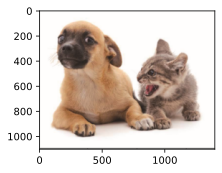

In [19]:
d2l.set_figsize()
print('input image shape:', img.permute(1, 2, 0).shape)
d2l.plt.imshow(img.permute(1, 2, 0));
print('output image shape:', out_img.shape)
d2l.plt.imshow(out_img);
# 因为 matplotlib（和 d2l.plt.imshow）默认把“最后一个维度”当作颜色通道。
# 而 PyTorch 的图像张量通常是：
# (C, H, W)
# 但 matplotlib 期望的是：
# (H, W, C)
# 所以必须 permute 一下。

In [20]:
# 全卷积网络[**用双线性插值的上采样初始化转置卷积层。对于$1\times 1$卷积层，我们使用Xavier初始化参数。**]
W = bilinear_kernel(num_classes, num_classes, 64)
net.transpose_conv.weight.data.copy_(W);

In [21]:
#读取数据集
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = d2l.load_data_voc(batch_size, crop_size)

read 1114 examples
read 1078 examples


In [ ]:
def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

num_epochs, lr, wd, devices = 5, 0.001, 1e-3, d2l.try_all_gpus()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

In [ ]:
def predict(img):
    X = test_iter.dataset.normalize_image(img).unsqueeze(0)
    pred = net(X.to(devices[0])).argmax(dim=1)
    return pred.reshape(pred.shape[1], pred.shape[2])

In [ ]:
def label2image(pred):
    colormap = torch.tensor(d2l.VOC_COLORMAP, device=devices[0])
    X = pred.long()
    return colormap[X, :]

In [ ]:
voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012')
test_images, test_labels = d2l.read_voc_images(voc_dir, False)
n, imgs = 4, []
for i in range(n):
    crop_rect = (0, 0, 320, 480)
    X = torchvision.transforms.functional.crop(test_images[i], *crop_rect)
    pred = label2image(predict(X))
    imgs += [X.permute(1,2,0), pred.cpu(),
             torchvision.transforms.functional.crop(
                 test_labels[i], *crop_rect).permute(1,2,0)]
d2l.show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n, scale=2);